# 01 - Exploratory Data Analysis

*Data Understanding*. Goal: understand conversion behaviour well enough to justify the preprocessing and feature-engineering decisions in the next notebooks.

This notebook loads data exclusively through `src.data.loader.load_sessions()` - never `pd.read_csv` directly - so the EDA, the API, and the dashboard all see identical data.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.utils.logging_config import setup_logging
from src.config.settings import get_settings
from src.data.loader import load_sessions

settings = get_settings()
setup_logging(level="INFO", log_file=settings.paths.log_file)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load data

In [2]:
settings = get_settings()
df = load_sessions(settings=settings)
print(df.shape)
df.head()

2026-09-02 12:09:17 | INFO     | src.data.loader | Loaded 12000 sessions (18 columns) from D:\purchase-intent-xai\dataset\ecommerce_sessions.csv. Conversion rate: 15.72%


(12000, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Converted
0,1,14.6517,0,0.0000,19,283.8812,0.008014,0.042106,68.579222,0.0,June,1,2,1,1,Returning_Visitor,False,1
1,1,18.9189,2,54.9802,15,1241.7638,0.032395,0.058101,0.000000,0.0,May,2,1,8,12,Returning_Visitor,False,0
2,1,30.0198,0,0.0000,23,365.3384,0.006802,0.029451,0.000000,0.0,Mar,1,2,1,3,New_Visitor,True,0
3,1,6.5566,0,0.0000,6,687.4788,0.039577,0.104395,0.000000,0.6,Dec,1,1,1,2,Returning_Visitor,True,0
4,1,112.5842,1,36.3523,19,656.4535,0.004594,0.038321,0.000000,0.0,Mar,2,1,2,5,Returning_Visitor,False,0


In [3]:
df.dtypes

Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay                  float64
Month                      category
OperatingSystems           category
Browser                    category
Region                     category
TrafficType                category
VisitorType                category
Weekend                    category
Converted                     int64
dtype: object

**Takeaway:** the four int-coded columns (`OperatingSystems`, `Browser`, `Region`, `TrafficType`) load as `category`, not `int64` - confirming the loader's dtype fix from Phase 2 is working.

## 2. Overall conversion rate

Conversion rate: 15.72%
Converted: 1886 | Not converted: 10114


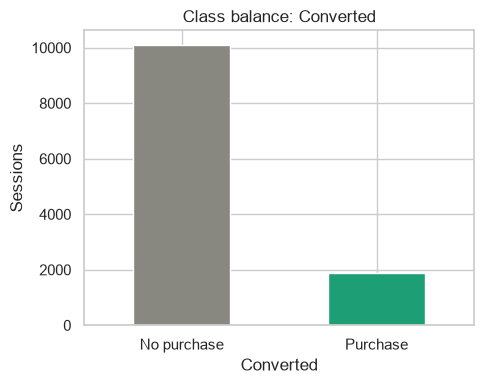

In [4]:
target = settings.data.target_column
conversion_rate = df[target].mean()
print(f"Conversion rate: {conversion_rate:.2%}")
print(f"Converted: {df[target].sum()} | Not converted: {(df[target] == 0).sum()}")

fig, ax = plt.subplots(figsize=(5, 4))
df[target].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#888780", "#1D9E75"])
ax.set_xticklabels(["No purchase", "Purchase"], rotation=0)
ax.set_ylabel("Sessions")
ax.set_title("Class balance: Converted")
plt.tight_layout()
plt.show()

**Takeaway:** roughly 1 in 6 sessions converts (~15.7%). This confirms the imbalance the brief flags - accuracy alone will be a misleading metric later, so PR-AUC/recall need to lead in the modelling notebook.

## 3. Buyer vs non-buyer behaviour

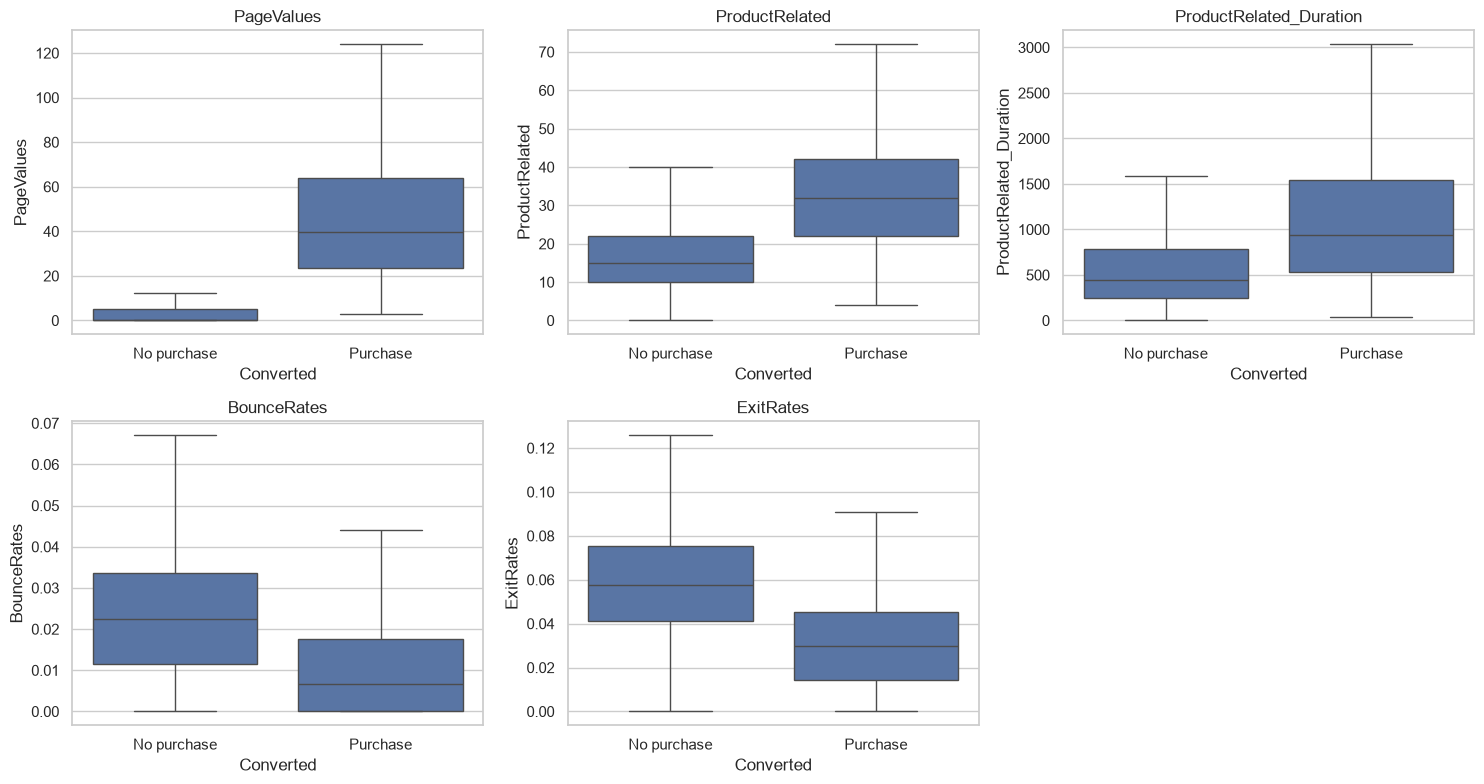

In [5]:
behaviour_cols = ["PageValues", "ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(behaviour_cols):
    sns.boxplot(data=df, x=target, y=col, ax=axes[i], showfliers=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No purchase", "Purchase"])
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [6]:
df.groupby(target)[behaviour_cols].median().rename(index={0: "No purchase", 1: "Purchase"})

,PageValues,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates
Converted,,,,,
No purchase,0.000000,15.0,447.7373,0.022436,0.057777
Purchase,39.487577,32.0,933.7821,0.006653,0.029669


**Takeaway:** buyers show markedly higher `PageValues` and spend more time on product pages, while `BounceRates`/`ExitRates` are lower for buyers - sessions that don't bounce and engage with products convert more. This is the strongest early signal for feature engineering (e.g. an engagement ratio).

**Leakage flag:** `PageValues` separates the classes so cleanly that it's worth treating as a suspect - see the note at the end of this notebook.

## 4. Seasonality: Month and SpecialDay

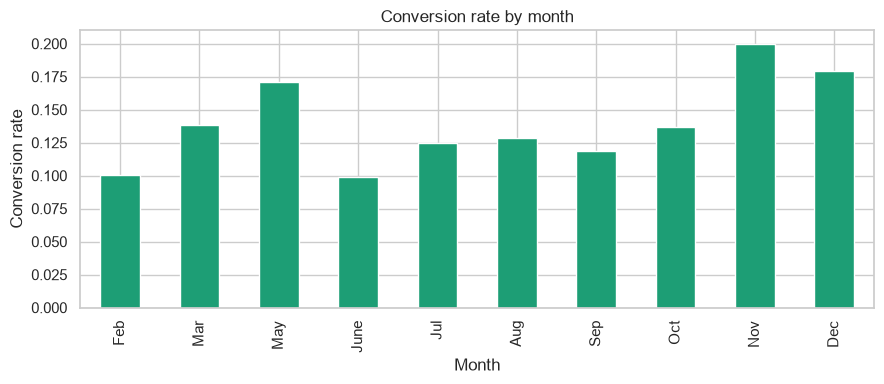

In [7]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_conv = df.groupby("Month", observed=True)[target].mean().reindex(
    [m for m in month_order if m in df["Month"].unique()]
)

fig, ax = plt.subplots(figsize=(9, 4))
month_conv.plot(kind="bar", ax=ax, color="#1D9E75")
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion rate by month")
plt.tight_layout()
plt.show()

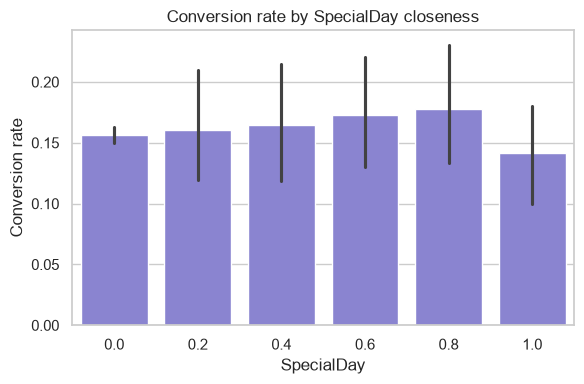

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x="SpecialDay", y=target, ax=ax, color="#7F77DD")
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion rate by SpecialDay closeness")
plt.tight_layout()
plt.show()

**Takeaway:** conversion rate varies noticeably by month (seasonal shopping peaks), while `SpecialDay` closeness alone does not show a strong monotonic relationship with conversion in this sample - worth checking interaction with `Month` in feature engineering rather than treating it as a strong standalone signal.

## 5. Returning vs new visitors

In [9]:
visitor_conv = df.groupby("VisitorType", observed=True)[target].agg(["mean", "count"])
visitor_conv.columns = ["conversion_rate", "n_sessions"]
visitor_conv.sort_values("conversion_rate", ascending=False)

,conversion_rate,n_sessions
VisitorType,,
Returning_Visitor,0.165680,10303
Other,0.150376,133
New_Visitor,0.101662,1564


In [10]:
fig = px.bar(
    visitor_conv.reset_index(),
    x="VisitorType", y="conversion_rate",
    color="VisitorType",
    title="Conversion rate by visitor type (interactive)",
    labels={"conversion_rate": "Conversion rate"},
    hover_data=["n_sessions"],
)
fig.update_layout(showlegend=False)
fig.show()

**Takeaway:** returning visitors convert noticeably more often(16.6%) then new visitors (10.2%), despite new visitors being a smaller share of sessions.

## 6. Correlation structure

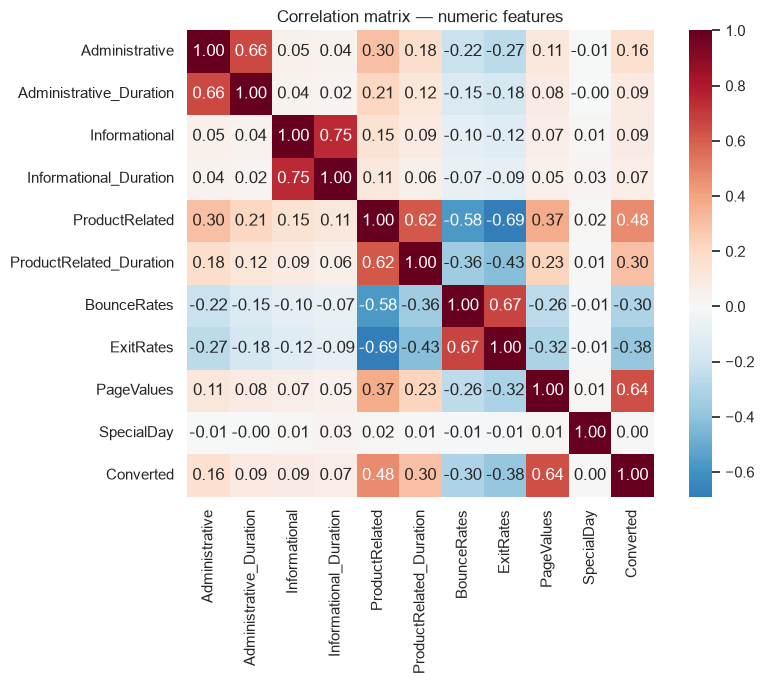

In [11]:
numeric_cols = settings.data.numeric_columns + [target]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

**Takeaway:** `PageValues` has by far the strongest correlation with `Converted`; the three `*_Duration` columns correlate with their respective page-count columns (expected, since more pages usually means more time), which is worth watching for redundancy in feature selection.

## 7. Interactive: engagement vs conversion

In [12]:
fig = px.scatter(
    df.sample(min(2000, len(df)), random_state=settings.random_seed),
    x="ProductRelated_Duration", y="PageValues",
    color=df.sample(min(2000, len(df)), random_state=settings.random_seed)[target].astype(str),
    labels={"color": "Converted"},
    title="Product page time vs PageValues, coloured by conversion (interactive, sampled)",
    opacity=0.6,
)
fig.show()

**Takeaway:** converting sessions (orange/1) cluster at higher `PageValues` regardless of time spent, reinforcing that `PageValues` is doing most of the separating work on its own - the leakage question below matters more because of this, not less.

## 8. Leakage note: PageValues

`PageValues` is the single strongest predictor in every view above. Per the brief, this needs an explicit, documented decision, not silent use:

- **If scoring happens late in a session** (e.g. at checkout initiation), `PageValues` is legitimately known and should be used.
- **If scoring happens early** (e.g. to trigger a mid-session discount nudge), `PageValues` may reflect pages the visitor hasn't seen yet, making it unavailable in practice - using it would be deployment leakage.

**Decision for this project:** *(fill in once the intended scoring moment is decided in the modelling notebook - e.g. "score at checkout initiation, so PageValues is retained" or "score early, so PageValues is excluded and reported separately as a stretch-goal ablation")*. Revisit this after the six-model comparison, per the stretch-goal ablation in §11 of the brief.

## Summary of takeaways

- Conversion rate is ~15.7% — imbalanced, PR-AUC/recall must lead over accuracy in modelling.
- `PageValues`, product-page engagement, and low bounce/exit rates separate buyers from non-buyers most clearly.
- Conversion has a seasonal component (by month); `SpecialDay` alone is weak.
- `VisitorType` is a weak standalone signal.
- `PageValues` needs an explicit leakage decision before being used in the final model.